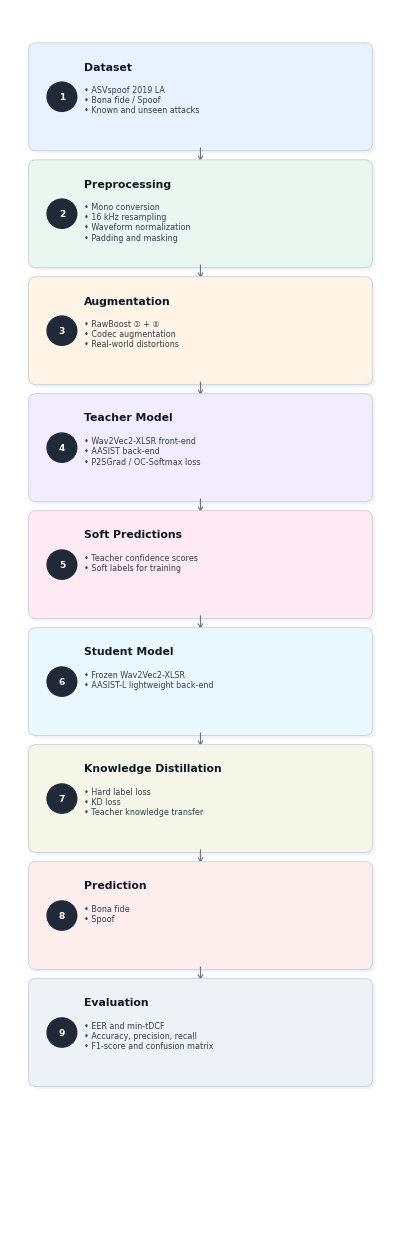

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import textwrap

# =========================
# Compact Two-Column Flowchart with Proper Text Wrapping
# =========================

steps = [
    {
        "title": "Dataset",
        "items": [
            " ",
            "ASVspoof 2019 LA",
            "Bona fide / Spoof",
            "Known and unseen attacks"
        ],
        "color": "#E8F1FF"
    },
    {
        "title": "Preprocessing",
        "items": [
            "Mono conversion",
            "16 kHz resampling",
            "Waveform normalization",
            "Padding and masking"
        ],
        "color": "#EAF7F0"
    },
    {
        "title": "Augmentation",
        "items": [
            "RawBoost ① + ②",
            "Codec augmentation",
            "Real-world distortions"
        ],
        "color": "#FFF4E6"
    },
    {
        "title": "Teacher Model",
        "items": [
            "Wav2Vec2-XLSR front-end",
            "AASIST back-end",
            "P2SGrad / OC-Softmax loss"
        ],
        "color": "#F1ECFF"
    },
    {
        "title": "Soft Predictions",
        "items": [
            "Teacher confidence scores",
            "Soft labels for training"
        ],
        "color": "#FFEAF3"
    },
    {
        "title": "Student Model",
        "items": [
            "Frozen Wav2Vec2-XLSR",
            "AASIST-L lightweight back-end"
        ],
        "color": "#EAF9FF"
    },
    {
        "title": "Knowledge Distillation",
        "items": [
            "Hard label loss",
            "KD loss",
            "Teacher knowledge transfer"
        ],
        "color": "#F4F7E8"
    },
    {
        "title": "Prediction",
        "items": [
            "Bona fide",
            "Spoof"
        ],
        "color": "#FDEDED"
    },
    {
        "title": "Evaluation",
        "items": [
            "EER and min-tDCF",
            "Accuracy, precision, recall",
            "F1-score and confusion matrix"
        ],
        "color": "#EEF2F7"
    }
]

def wrap_items(items, width=34):
    """
    Converts list items into wrapped multiline text.
    This prevents text from going outside the box.
    """
    wrapped_lines = []
    for item in items:
        wrapped = textwrap.wrap(item, width=width)
        if wrapped:
            wrapped_lines.append("• " + wrapped[0])
            for line in wrapped[1:]:
                wrapped_lines.append("  " + line)
    return "\n".join(wrapped_lines)

# =========================
# Figure Setup
# =========================

fig, ax = plt.subplots(figsize=(4.1, 12.5))
fig.patch.set_facecolor("white")

ax.set_xlim(0, 4.1)
ax.set_ylim(0, len(steps) * 1.35 + 1.2)
ax.axis("off")

box_width = 3.55
box_height = 1.02
x = 0.28
y_start = len(steps) * 1.32

# =========================
# Title
# =========================





# =========================
# Draw Flowchart
# =========================

for i, step in enumerate(steps):
    y = y_start - i * 1.28

    # Shadow
    shadow = FancyBboxPatch(
        (x + 0.03, y - 0.03),
        box_width,
        box_height,
        boxstyle="round,pad=0.08,rounding_size=0.08",
        linewidth=0,
        facecolor="#D1D5DB",
        alpha=0.30
    )
    ax.add_patch(shadow)

    # Main box
    box = FancyBboxPatch(
        (x, y),
        box_width,
        box_height,
        boxstyle="round,pad=0.08,rounding_size=0.08",
        linewidth=0.7,
        edgecolor="#CBD5E1",
        facecolor=step["color"]
    )
    ax.add_patch(box)

    # Number circle
    circle = plt.Circle(
        (x + 0.28, y + box_height / 2),
        0.16,
        color="#1F2937"
    )
    ax.add_patch(circle)

    ax.text(
        x + 0.28,
        y + box_height / 2,
        str(i + 1),
        ha="center",
        va="center",
        fontsize=6.5,
        fontweight="bold",
        color="white"
    )

    # Title
    ax.text(
        x + 0.52,
        y + box_height - 0.18,
        step["title"],
        ha="left",
        va="center",
        fontsize=7.8,
        fontweight="bold",
        color="#111827"
    )

    # Wrapped items
    item_text = wrap_items(step["items"], width=34)

    ax.text(
        x + 0.52,
        y + box_height - 0.38,
        item_text,
        ha="left",
        va="top",
        fontsize=5.8,
        color="#374151",
        linespacing=1.18
    )

    # Arrow
    if i < len(steps) - 1:
        arrow = FancyArrowPatch(
            (x + box_width / 2, y - 0.02),
            (x + box_width / 2, y - 0.23),
            arrowstyle="->",
            mutation_scale=8,
            linewidth=0.8,
            color="#64748B"
        )
        ax.add_patch(arrow)

# =========================
# Save Files
# =========================

plt.tight_layout()

plt.savefig(
    "methodology_flowchart_two_column_wrapped.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "methodology_flowchart_two_column_wrapped.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()